In [1]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

import os
##### Change this! #####
# grab colors for easy graphing
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
test_data_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/testData")

minesColors = {
    "paleBlue":     "#CFDCE9",
    "lightBlue":    "#879EC3",
    "blasterBlue":  "#09396C",
    "darkBlue":     "#21314D",
    "coloradoRed":  "#CC4628",
    "lightGray":    "#AEB3B8",
    "silver":       "#81848A",
    "darkGray":     "#75757D",
    "goldenTech":   "#F1B91A",
    "earthBlue":    "#0272DE",
    "mutedBlue":    "#57A2BD",
    "energyYellow": "#F0F600",
    "envrGreen":    "#80C342",
    "redFlannel":   "#B42024"
    }

# Module Testing

## Set-Up

Defining functons.

In [3]:
# Defining a function that grabs weights & makes prediction
def load_lstm_and_predict(input_data, weights_path, input_size, hidden_size, num_layers, output_size):
    """
    Load LSTM weights and make predictions using a function-based approach.
    
    Args:
        input_data (torch.Tensor): Input tensor of shape (batch_size, seq_length, input_size).
        weights_path (str): Path to the .pt file containing model weights.
        input_size (int): Number of input features per time step.
        hidden_size (int): Number of features in the hidden state.
        num_layers (int): Number of recurrent layers.
        output_size (int): Number of output features.
    
    Returns:
        torch.Tensor: Predictions from the model.
    """
    # Define the LSTM and linear layers
    lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    fc = nn.Linear(hidden_size, output_size)
    
    # Load weights
    state_dict = torch.load(weights_path)
    
    # Map LSTM weights
    lstm_state_dict = {k.replace("lstm.", ""): v for k, v in state_dict.items() if k.startswith("lstm.")}
    lstm.load_state_dict(lstm_state_dict)
    
    # Map fully connected (linear) layer weights
    if "linear.weight" in state_dict and "linear.bias" in state_dict:
        fc_state_dict = {
            "weight": state_dict["linear.weight"],
            "bias": state_dict["linear.bias"]
        }
        fc.load_state_dict(fc_state_dict)
    else:
        raise RuntimeError("Missing keys for linear layer in state_dict. Check the key names.")
    
    # Set evaluation mode
    lstm.eval()
    fc.eval()
    
    # Perform forward pass
    with torch.no_grad():
        lstm_out, _ = lstm(input_data)  # Get output from LSTM
        lstm_pred = fc(lstm_out)  # Pass through the fully connected layer
    
    # Apply sigmoid and scaling to each column
    predictions = torch.zeros_like(lstm_pred)
    predictions[:, :, 0] = torch.sigmoid(lstm_pred[:, :, 0]) * 0.000726 + 0.0 # satdk
    predictions[:, :, 1] = torch.sigmoid(lstm_pred[:, :, 1]) * (0.0018 - 0.0000018) + 0.0000018 # Cgw
    predictions[:, :, 2] = torch.sigmoid(lstm_pred[:, :, 2]) * 21.94 + 0.0 # bb
    predictions[:, :, 3] = torch.sigmoid(lstm_pred[:, :, 3]) * (1.0 - 0.20554) + 0.20554 # smcmax
    predictions[:, :, 4] = torch.sigmoid(lstm_pred[:, :, 4]) * 1.0 + 0.0 # slop
    predictions[:, :, 5] = torch.sigmoid(lstm_pred[:, :, 5]) * (0.25 - 0.01) + 0.01 # max_gw
    predictions[:, :, 6] = torch.sigmoid(lstm_pred[:, :, 6]) * (8.0 - 1.0) + 1.0 # expon
    predictions[:, :, 7] = torch.sigmoid(lstm_pred[:, :, 7]) * 1.0 + 0.0 # K_lf
    predictions[:, :, 8] = torch.sigmoid(lstm_pred[:, :, 8]) * 1.0 + 0.0 # K_nash
    predictions[:, :, 9] = torch.sigmoid(lstm_pred[:, :, 9]) * (0.95 - 0.05) + 0.05 # saptsi
    return predictions

def calculate_nse(observed, simulated):
    """
    Calculate the Nash-Sutcliffe Efficiency (NSE) between observed and simulated data.

    Parameters:
    observed (list or numpy array): Observed data values.
    simulated (list or numpy array): Simulated data values.

    Returns:
    float: The NSE value.
    """
    # Convert inputs to numpy arrays
    observed = np.array(observed)
    simulated = np.array(simulated)

    # Ensure the observed and simulated arrays have the same length
    if len(observed) != len(simulated):
        raise ValueError("Observed and simulated data must have the same length.")

    # Calculate the numerator and denominator of the NSE formula
    numerator = np.sum((observed - simulated) ** 2)
    denominator = np.sum((observed - np.mean(observed)) ** 2)

    # Avoid division by zero
    if denominator == 0:
        raise ValueError("The denominator of the NSE calculation is zero.")

    # Compute NSE
    nse = 1 - (numerator / denominator)

    return nse

Import trained model that makes predictions based on average of the LSTM output. Also grab calibrated parameters (this ver is via basin_id in config, later version grabs it differently.)

In [4]:
import neuralhydrology.utils.CFE_modules as module
from neuralhydrology.utils.dCFE_utils import get_dcfe_params, expand_dcfe_params_along_batch_dim

# Grab config file so we can see if the code works
config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/2basinTest_devMultiBasin.yml')
config = Config(config_path, dev_mode=True)

# Define the path to the testData folder & grab data
inputLSTMFile = pd.read_csv(test_data_dir/'02177000_lstm_input.csv')

# Normalize the lstm input data
input_lstm = torch.zeros(config.batch_size, len(inputLSTMFile), len(inputLSTMFile.columns) - 1) # [batch_size = 2, time_steps, forcing]
# ^^^wierd batch size to minimum amout of code edits needed. Info will only be stored in [0,:,:]
input_lstm[0, :, 0] = torch.Tensor((inputLSTMFile['PRCP(mm/day)_nldas'].values - np.mean(inputLSTMFile['PRCP(mm/day)_nldas'].values))/
                                   np.std(inputLSTMFile['PRCP(mm/day)_nldas'].values))
input_lstm[0, :, 1] = torch.Tensor((inputLSTMFile['PRCP(mm/day)_maurer'].values - np.mean(inputLSTMFile['PRCP(mm/day)_maurer'].values))/
                                   np.std(inputLSTMFile['PRCP(mm/day)_maurer'].values))
input_lstm[0, :, 2] = torch.Tensor((inputLSTMFile['prcp(mm/day)_daymet'].values - np.mean(inputLSTMFile['prcp(mm/day)_daymet'].values))/
                                   np.std(inputLSTMFile['prcp(mm/day)_daymet'].values))
input_lstm[0, :, 3] = torch.Tensor((inputLSTMFile['srad(W/m2)_daymet'].values - np.mean(inputLSTMFile['srad(W/m2)_daymet'].values))/
                                   np.std(inputLSTMFile['srad(W/m2)_daymet'].values))
input_lstm[0, :, 4] = torch.Tensor((inputLSTMFile['tmax(C)_daymet'].values - np.mean(inputLSTMFile['tmax(C)_daymet'].values))/
                                   np.std(inputLSTMFile['tmax(C)_daymet'].values))
input_lstm[0, :, 5] = torch.Tensor((inputLSTMFile['tmin(C)_daymet'].values - np.mean(inputLSTMFile['tmin(C)_daymet'].values))/
                                   np.std(inputLSTMFile['tmin(C)_daymet'].values))
input_lstm[0, :, 6] = torch.Tensor((inputLSTMFile['vp(Pa)_daymet'].values - np.mean(inputLSTMFile['vp(Pa)_daymet'].values))/
                                   np.std(inputLSTMFile['vp(Pa)_daymet'].values))

# Grab config file that trained this model
config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/TestdCFEDaily_run02177000_CalibratedSpinUp15epoch_2302_114438/config.yml')
config = Config(config_path, dev_mode=True)

# Grab results from evaluated model (This is trained using Avg Params for Prediction)
run_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/TestdCFEDaily_run02177000_CalibratedSpinUp15epoch_2302_114438")
with open(run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    dCFE_results_avgParams = pickle.load(fp)

input_size = input_lstm.shape[2] # the num of forcings input into lstm, tmax, tmin, precip etc etc
hidden_size = config.hidden_size
num_layers = 1
output_size = 10 # satdk, cgw, and 7 other outputs
weights_path = run_dir/"model_epoch030.pt"

torch.set_printoptions(precision=16)

# Example input data (batch_size=1, seq_length=5, input_size=10)
input_data = input_lstm

# Make predictions
LSTM_params = load_lstm_and_predict(input_data, weights_path, input_size, hidden_size, num_layers, output_size)

dates_param = pd.date_range(start='1998-04-04', periods=input_lstm.shape[1], freq='D')

In [5]:
input_cfe = torch.zeros(config.batch_size, input_lstm.shape[1], 4) #[ "batch_size", forcings, time_step]
input_cfe[0, :, 0] = torch.tensor(inputLSTMFile['PRCP(mm/day)_nldas'].values) # 1998 - 2000, 2 water years
input_cfe[0, :, 1] = torch.tensor(inputLSTMFile['tmin(C)_daymet'].values)
input_cfe[0, :, 2] = torch.tensor(inputLSTMFile['tmax(C)_daymet'].values)
input_cfe[0, :, 3] = torch.tensor(inputLSTMFile['srad(W/m2)_daymet'].values)

temp_soil_params_validate, temp_basinCharacteristics_validate = get_dcfe_params(config, 'cpu')
# store them as calibrated parameters for the calibrated-CFE comparison


calibrated_soil_params_validate = expand_dcfe_params_along_batch_dim(temp_soil_params_validate, config.batch_size)
calibrated_basinCharacteristics_validate = expand_dcfe_params_along_batch_dim(temp_basinCharacteristics_validate, config.batch_size)


## Run the model incrementally. 

In [6]:
default_params = {
    'soil_params': calibrated_soil_params_validate,
    'basinCharacteristics': calibrated_basinCharacteristics_validate
    }

constants, cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.initialize_basin_constants(
    cfg= config,
    conceptual_forcing= input_cfe,
    cfe_params= default_params,
    hourly=True
    )

# label parameters from LSTM for just one step
timestep_params = {
    'satdk': LSTM_params[:, 0, 0],
    'Cgw': LSTM_params[:, 0, 1],
    'bb': LSTM_params[:, 0, 2],
    'smcmax': LSTM_params[:, 0, 3],
    'slop': LSTM_params[:, 0, 4],
    'max_gw_storage': LSTM_params[:, 0, 5],
    'expon': LSTM_params[:, 0, 6],
    'K_lf': LSTM_params[:, 0, 7],
    'K_nash': LSTM_params[:, 0, 8],
    'satpsi': LSTM_params[:, 0, 9]
    }

cfe_params, gw_reservoir, soil_reservoir = module.timestep_basin_constants(
    conceptual_forcing_timestep= input_cfe[:, 0, 0:3],
    gw_reservoir= gw_reservoir,
    soil_reservoir= soil_reservoir,
    cfe_params= cfe_params,
    constants= constants,
    timestep_params= timestep_params
    )

flux = module.initialize_flux_timestep(
    conceptual_forcing_timestep= input_cfe[:, 0, 0:3],
    flux= flux)

flux = module.get_and_calculate_input_rainfall_and_ET(
    conceptual_forcing_timestep= input_cfe[:, 0, 0:3],
    flux= flux,
    hourly= True,
    constants= constants
    )

flux = module.calculate_evaporation_from_rainfall(
    flux= flux
    )

flux, soil_reservoir = module.calculate_evaporation_from_soil(
    flux= flux,
    soil_reservoir= soil_reservoir,
    constants= constants
    )

flux, soil_reservoir = module.run_Schaake_subroutine(
    flux= flux,
    soil_reservoir= soil_reservoir,
    constants= constants,
    cfe_params= cfe_params
    )

flux, soil_reservoir = module.adjust_and_track_runoff_infiltration(
    flux= flux,
    soil_reservoir= soil_reservoir
    )

flux, soil_reservoir = module.run_classic_soil_moisture_subroutine(
    flux = flux,
    soil_reservoir= soil_reservoir
    )

flux, soil_reservoir = module.adjust_from_soil_outflux(
    flux= flux,
    constants= constants,
    soil_reservoir= soil_reservoir
    )

flux, gw_reservoir = module.percolation_and_lateral_flow(
    flux= flux,
    gw_reservoir= gw_reservoir
    )

flux, gw_reservoir = module.calculate_gw_reservoir_flux(
    timestep_conceptual_forcing= input_cfe[:, 0, 0:2],
    flux= flux,
    gw_reservoir= gw_reservoir,
    cfe_params= cfe_params
    )

flux, routing_info = module.calculate_convolutional_integral_for_GIUH(
    flux= flux,
    routing_info= routing_info,
    cfe_params= cfe_params
    )

flux, routing_info, cfe_params = module.run_nash_cascade(
    flux= flux,
    routing_info= routing_info,
    cfe_params= cfe_params
    )


One time-step works!

# Verify Model to CFE & Previous Study
The goal of this section is to compare the existing dCFE code (as of 20241215) to CFE hourly outputs: https://github.com/NWC-CUAHSI-Summer-Institute/cfe_py/blob/main/cat58_test_compare.csv
The forcing for the same time period is: https://github.com/NWC-CUAHSI-Summer-Institute/cfe_py/blob/main/cat58_01Dec2015.csv
The basin settings (since baasin id unknown) is here: https://github.com/NWC-CUAHSI-Summer-Institute/cfe_py/blob/main/bmi_cfe.py

Note that the forcing file as TMP_2maboveground which I assume is temperature in (K), so it needs to be converted to C before being used. And the initialized_basin_constants is adaped based on the bmi_cfe.py file. 

## Running CFE

In [7]:
device = 'cpu'
batch_size = config.batch_size

forcingFile = pd.read_csv(test_data_dir/'cat58_01Dec2015.csv')
forcingsTest = torch.zeros(batch_size, forcingFile.shape[0], 3) #[ "batch_size", forcings, time_step]

forcingsTest[:, :, 0] = (torch.tensor(forcingFile.loc[:,'precip_rate']) * 1000 * 3600) # m/s to mm/hr
forcingsTest[:, :, 1] = (torch.tensor(forcingFile.loc[:,'TMP_2maboveground']) - 273.15) # K to C
forcingsTest[:, :, 2] = torch.tensor(forcingFile.loc[:,'DSWRF_surface']) # same unit as camels

In [8]:
# empty vector to store output
Discharge = torch.zeros(forcingsTest.shape[1], 8)
    
TShirt_basinCharacteristics = {
        'catchment_area_km2': 15.617167355002097 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size), 
        'refkdt': 3.8266861353378374 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size),
        'max_gw_storage': 16 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size),
        'Cgw': 0.01*torch.tensor(1.0).repeat(batch_size),
        'expon': 6.0 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size),
        #gw_storage = 0.05 * torch.ones((  batch_size,  shape[1]), dtype=torch.float32, device= device)
        'alpha_fc': 0.33 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size ),
        'K_nash': 0.03 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), 
        'K_lf': 0.01 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), 
        'nash_storage': torch.zeros((  batch_size,2), dtype=torch.float32, device= device),
        'giuh_ordinates': torch.tensor([0.1, 0.35, 0.2, 0.14, 0.1, 0.06, 0.05], dtype=torch.float32, device= device)
    } 

TShirt_soil_params = {
        'depth': 2.0 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), # not sure where they got these values, they don't match CAMELS, [m]
        'bb': 4.05 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), # exponent on Clapp-Hornberger function, part of calibration
        'satdk': 0.00000338*torch.tensor(1.0).repeat(  batch_size),
        'satpsi': 0.355 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), 
        'slop': 1 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), # slope coefficient, part of calibration
        'smcmax': 0.439 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), # maximum soil moisture content [m3/m3], part of calibration
        'wltsmc': 0.066* torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size),
        'D': 2.0 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size),
        'mult': 1000.0 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size)
    }

TShirt_params = {
    'soil_params': TShirt_soil_params,
    'basinCharacteristics': TShirt_basinCharacteristics
}

# initialize before run
constants, cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.initialize_basin_constants(
    cfg= config,
    conceptual_forcing= forcingsTest,
    cfe_params= TShirt_params,
    hourly= True
    )


# unique to T-shirt
gw_reservoir['storage_m'] = gw_reservoir['storage_max_m'].clone() * 0.03125
soil_reservoir['storage_m'] = 0.667 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size) #factor was 0.6 before

timestep_params_TShirt = {
    'satdk': TShirt_soil_params['satdk'],
    'Cgw': TShirt_basinCharacteristics['Cgw'],
    'bb': TShirt_soil_params['bb'],
    'smcmax': TShirt_soil_params['smcmax'],
    'slop': TShirt_soil_params['slop'],
    'max_gw_storage': TShirt_basinCharacteristics['max_gw_storage'],
    'expon': TShirt_basinCharacteristics['expon'],
    'K_lf': TShirt_basinCharacteristics['K_lf'],
    'K_nash': TShirt_basinCharacteristics['K_nash'],
    'satpsi': TShirt_soil_params['satpsi']
    }


for i in range(forcingsTest.shape[1]):
    cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.timestep_CFE_new(
        x_conceptual_timestep= forcingsTest[:, i, :],
        cfe_params=cfe_params,
        timestep_parameters= timestep_params_TShirt,
        constants= constants,
        gw_reservoir= gw_reservoir,
        soil_reservoir= soil_reservoir,
        routing_info= routing_info,
        flux = flux,
        hourly= True
        )

    Discharge[i, 0] = flux['Qout_m'][0]
    Discharge[i, 1] = flux['giuh_runoff_m'][0] 
    Discharge[i, 2] = flux['nash_lateral_runoff_m'][0]
    Discharge[i, 3] = flux['from_deep_gw_to_chan_m'][0]
    Discharge[i, 4] = flux['surface_runoff_depth_m'][0]
    Discharge[i, 5] = flux['actual_et_m_per_timestep'][0] # total ET
    Discharge[i, 6] = soil_reservoir['storage_m'][0] # soil water storage
    Discharge[i, 7] = gw_reservoir['storage_m'][0] # gw storage


# grab observations from acutal CFE
compareFile = pd.read_csv(test_data_dir/'cat58_test_compare.csv')

## Comparison to T-Shirt CFE

This only looks at one section of the whole time series, the same section that the original comparison did (not sure why they picked this specific section).

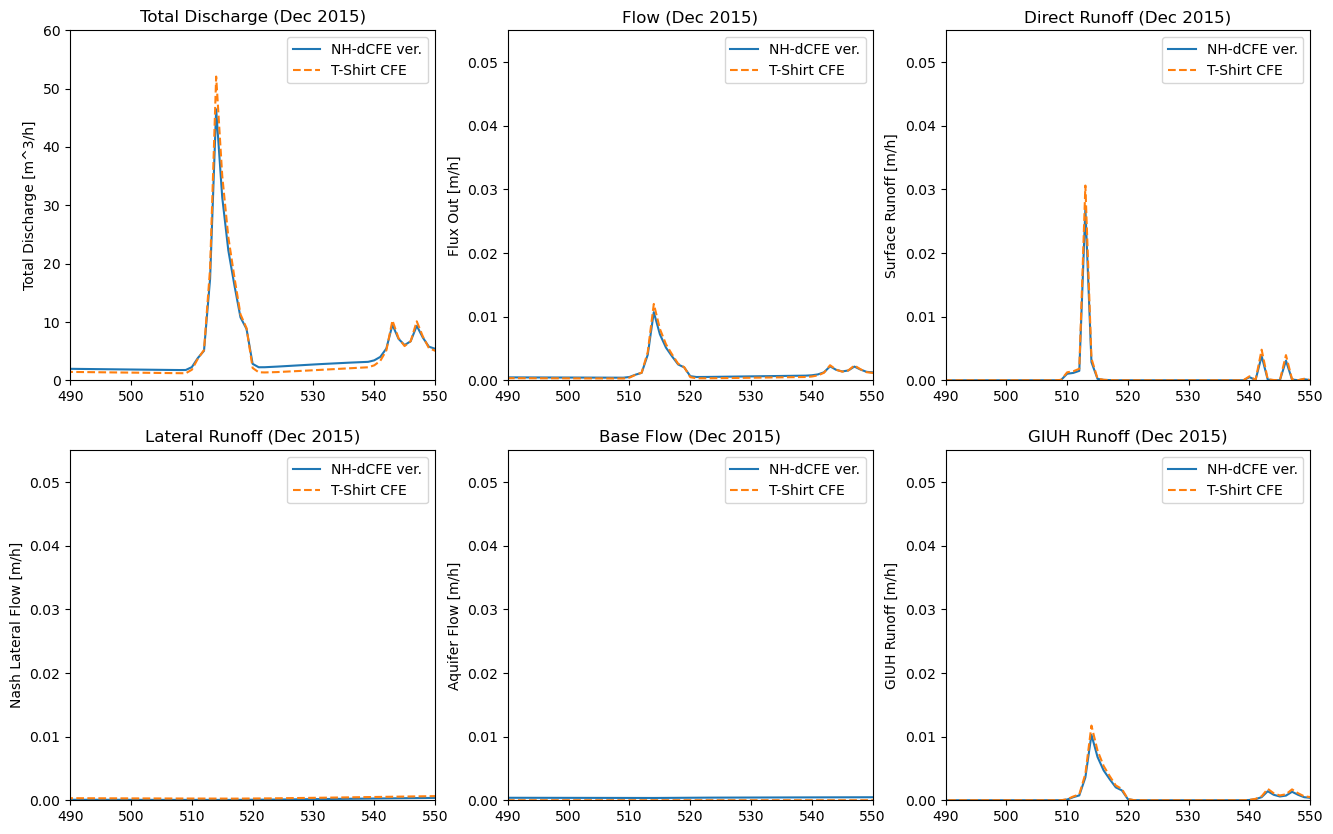

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(16,10))

ax[0,0].plot(compareFile['Time Step'], Discharge[:,0]*15.617167355002097 * 1000000.0 / 3600 , label="NH-dCFE ver.")
ax[0,0].plot(compareFile['Time Step'], compareFile['Total Discharge'], label="T-Shirt CFE", linestyle= 'dashed')
# Set labels and title
ax[0,0].set_ylabel("Total Discharge [m^3/h]")
ax[0,0].set_title(f"Total Discharge (Dec 2015)")
# Set axis limits
ax[0,0].set_xlim([490, 550]) 
ax[0,0].set_ylim([0, 60])  
ax[0,0].legend()

ax[0,1].plot(compareFile['Time Step'], Discharge[:,0], label="NH-dCFE ver.")
ax[0,1].plot(compareFile['Time Step'], compareFile['Flow'], label="T-Shirt CFE", linestyle= 'dashed')
# Set labels and title
ax[0,1].set_ylabel("Flux Out [m/h]")
ax[0,1].set_title(f"Flow (Dec 2015)")
# Set axis limits
ax[0,1].set_xlim([490, 550])  
ax[0,1].set_ylim([0, 0.055])  
ax[0,1].legend()

ax[0,2].plot(compareFile['Time Step'], Discharge[:,4], label="NH-dCFE ver.")
ax[0,2].plot(compareFile['Time Step'], compareFile['Direct Runoff'],label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[0,2].set_ylabel("Surface Runoff [m/h]")
ax[0,2].set_title(f"Direct Runoff (Dec 2015)")
# Set axis limits
ax[0,2].set_xlim([490, 550]) 
ax[0,2].set_ylim([0, 0.055])  
ax[0,2].legend()

ax[1,0].plot(compareFile['Time Step'], Discharge[:,2], label="NH-dCFE ver.")
ax[1,0].plot(compareFile['Time Step'], compareFile['Lateral Flow'],label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[1,0].set_ylabel("Nash Lateral Flow [m/h]")
ax[1,0].set_title(f"Lateral Runoff (Dec 2015)")
# Set axis limits
ax[1,0].set_xlim([490, 550]) 
ax[1,0].set_ylim([0, 0.055])   
ax[1,0].legend()

ax[1,1].plot(compareFile['Time Step'], Discharge[:,3], label="NH-dCFE ver.")
ax[1,1].plot(compareFile['Time Step'], compareFile['Base Flow'],label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[1,1].set_ylabel("Aquifer Flow [m/h]")
ax[1,1].set_title(f"Base Flow (Dec 2015)")
# Set axis limits
ax[1,1].set_xlim([490, 550]) 
ax[1,1].set_ylim([0, 0.055])  
ax[1,1].legend()

ax[1,2].plot(compareFile['Time Step'], Discharge[:,1], label="NH-dCFE ver.")
ax[1,2].plot(compareFile['Time Step'], compareFile['GIUH Runoff'], label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[1,2].set_ylabel("GIUH Runoff [m/h]")
ax[1,2].set_title(f"GIUH Runoff (Dec 2015)")
# Set axis limits
ax[1,2].set_xlim([490, 550]) 
ax[1,2].set_ylim([0, 0.055])   
ax[1,2].legend()

They are all very very close. So this passes.

## Comparison to HydroShare Calibrated Params
The HydroShare calibrated files have runoff from 2009-10-01 00:00:00 to 2010-09-30 23:00:00. Grab the HydroShare info from the .json file.

In [44]:
import json

# filepath: Replace with the path to your JSON file
file_path_validate = "/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/CFE_Calibrated_Config/runs/cat_02177000_testrun_results.json"

# Load the JSON file
with open(file_path_validate, 'r') as file:
    data_validate = json.load(file)

# Extract the "simulated_Q(mm/h)" values
runoff_simulation_validate = data_validate.get("simulated_Q(mm/h)", [])

Grab forcings.

In [48]:
# load forcing
forcingFile_validate = pd.read_csv(test_data_dir/'02177000_hourly_CFE2009-10.csv')
forcingsValidate = torch.zeros(batch_size, forcingFile_validate.shape[0], 3) #[ "batch_size", time_step, forcings]
# grab input forcings
forcingsValidate[0, :, 0] = torch.tensor(forcingFile_validate.loc[:,'total_precipitation'])
forcingsValidate[0, :, 1] = torch.tensor(forcingFile_validate.loc[:,'temperature'])
forcingsValidate[0, :, 2] = torch.tensor(forcingFile_validate.loc[:,'shortwave_radiation'])

# Grab config file that has the correct settings for hourly validation (mostly formality to not break the code)
config_path_validate = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/basin_dCFEwPETHourly.yml')
config_validate = Config(config_path_validate, dev_mode=True)

Grab the HydroShare parameteres.

In [59]:
batch_size = config_validate.batch_size
device = 'cpu'
temp_soil_params_validate, temp_basinCharacteristics_validate = get_dcfe_params(config_validate, device=device)
# store them as calibrated parameters for the calibrated-CFE comparison

calibrated_soil_params_validate = expand_dcfe_params_along_batch_dim(temp_soil_params_validate, batch_size)
calibrated_basinCharacteristics_validate = expand_dcfe_params_along_batch_dim(temp_basinCharacteristics_validate, batch_size)
cfe_params_validate = {
    'soil_params': calibrated_soil_params_validate,
    'basinCharacteristics': calibrated_basinCharacteristics_validate
    }

timestep_params_calibrated = {
    'satdk': calibrated_soil_params_validate['satdk'],
    'Cgw': calibrated_basinCharacteristics_validate['Cgw'],
    'bb': calibrated_soil_params_validate['bb'],
    'smcmax': calibrated_soil_params_validate['smcmax'],
    'slop': calibrated_soil_params_validate['slop'],
    'max_gw_storage': calibrated_basinCharacteristics_validate['max_gw_storage'],
    'expon': calibrated_basinCharacteristics_validate['expon'],
    'K_lf': calibrated_basinCharacteristics_validate['K_lf'],
    'K_nash': calibrated_basinCharacteristics_validate['K_nash'],
    'satpsi': calibrated_soil_params_validate['satpsi']
    }


# empty vector to store output
Discharge_validate = torch.zeros(forcingsValidate.shape[1], 8)

# initialize before run
constants, cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.initialize_basin_constants(
    cfg= config_validate,
    conceptual_forcing= forcingsValidate,
    cfe_params= cfe_params_validate,
    hourly= True
    )

for i in range(forcingsValidate.shape[1]):
    cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.timestep_CFE_new(
        x_conceptual_timestep= forcingsValidate[:, i, :],
        cfe_params=cfe_params,
        timestep_parameters= timestep_params_calibrated,
        constants= constants,
        gw_reservoir= gw_reservoir,
        soil_reservoir= soil_reservoir,
        routing_info= routing_info,
        flux = flux,
        hourly= True
        )

    Discharge_validate[i, 0] = flux['Qout_m'][0]
    Discharge_validate[i, 1] = flux['giuh_runoff_m'][0] 
    Discharge_validate[i, 2] = flux['nash_lateral_runoff_m'][0]
    Discharge_validate[i, 3] = flux['from_deep_gw_to_chan_m'][0]
    Discharge_validate[i, 4] = flux['surface_runoff_depth_m'][0]
    Discharge_validate[i, 5] = flux['actual_et_m_per_timestep'][0] # total ET
    Discharge_validate[i, 6] = soil_reservoir['storage_m'][0] # soil water storage
    Discharge_validate[i, 7] = gw_reservoir['storage_m'][0] # gw storage


Graphing.

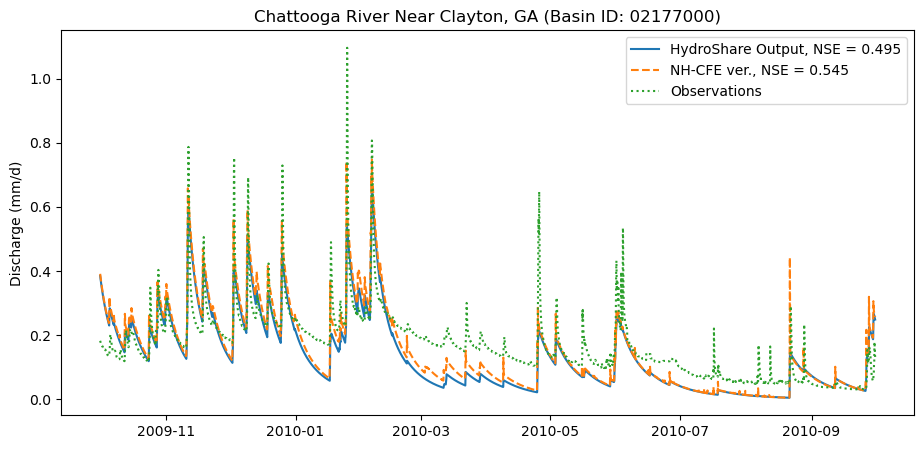

In [60]:
length_validate = len(runoff_simulation_validate)
observation_validate = forcingFile_validate.loc[:,'observation']
date_validate = pd.date_range(start='2009-10-01', periods=length_validate, freq='h')

# Calculate NSE for the validation data and HydroShare output
NSE_HydroShare = calculate_nse(observation_validate[-length_validate:], runoff_simulation_validate)
NSE_NHCFE = calculate_nse(observation_validate[-length_validate:], Discharge_validate[-length_validate:,0] * 1000)

# Plot observations and simulations
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(date_validate, runoff_simulation_validate, label=f"HydroShare Output, NSE = {NSE_HydroShare:.3f}")
ax.plot(date_validate, Discharge_validate[-length_validate:,0] * 1000, 
        label=f"NH-CFE ver., NSE = {NSE_NHCFE:.3f}", linestyle='dashed')
ax.plot(date_validate, observation_validate[-length_validate:], 
        label="Observations", linestyle='dotted')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title("Chattooga River Near Clayton, GA (Basin ID: 02177000)")
_ = ax.legend()

Considering we don't know what the HydroShare experiment uses for PET or forcings, or/if it had spin-up or not I think they do match up. The NSE in the HydroShare study is 0.505 and it is calculated to be 0.495 compared to the CAMELS hourly dischage data (combination of two sources). We have 1yr spin off, uses different forcings to the HydroShare experiment, and the CFE in NH results in NSE = 0.545.

# Trained dCFE Model (Avg Params vs. Dynamic Params)
To do this, there are several steps. First, we'll need to examine parameters from a trained LSTM by
1. Grab data needed for LSTM, normalize them
2. Grab wights from trained LSTM model, use them to predict params
3. Graph params over time 

Second, verify "manually" computed outputs via CFE match NH computed outputs, & compare to "calibrated params"

4. Grab evaluated results from trained NH-dCFE model
5. Use calibrated fixed parameters to predict for same time period, and
6. Use time-varying parameters from before to predict for the same time period, compare runoff to both previous realizations (4, 5).

Thirdly, examine internal states and other quantity of interest.

7. Graph internal states overtime, make sure to have correct units

## Preparating Forcings & MISC Functions

Grab forcings that will be fed into the LSTM.

In [51]:
# Define the path to the testData folder & grab data
inputLSTMFile = pd.read_csv(test_data_dir/'02177000_lstm_input.csv')

# Normalize the lstm input data
input_lstm = torch.zeros(2, len(inputLSTMFile), len(inputLSTMFile.columns) - 1) # [batch_size = 2, time_steps, forcing]
# ^^^wierd batch size to minimum amout of code edits needed. Info will only be stored in [0,:,:]
input_lstm[0, :, 0] = torch.Tensor((inputLSTMFile['PRCP(mm/day)_nldas'].values - np.mean(inputLSTMFile['PRCP(mm/day)_nldas'].values))/
                                   np.std(inputLSTMFile['PRCP(mm/day)_nldas'].values))
input_lstm[0, :, 1] = torch.Tensor((inputLSTMFile['PRCP(mm/day)_maurer'].values - np.mean(inputLSTMFile['PRCP(mm/day)_maurer'].values))/
                                   np.std(inputLSTMFile['PRCP(mm/day)_maurer'].values))
input_lstm[0, :, 2] = torch.Tensor((inputLSTMFile['prcp(mm/day)_daymet'].values - np.mean(inputLSTMFile['prcp(mm/day)_daymet'].values))/
                                   np.std(inputLSTMFile['prcp(mm/day)_daymet'].values))
input_lstm[0, :, 3] = torch.Tensor((inputLSTMFile['srad(W/m2)_daymet'].values - np.mean(inputLSTMFile['srad(W/m2)_daymet'].values))/
                                   np.std(inputLSTMFile['srad(W/m2)_daymet'].values))
input_lstm[0, :, 4] = torch.Tensor((inputLSTMFile['tmax(C)_daymet'].values - np.mean(inputLSTMFile['tmax(C)_daymet'].values))/
                                   np.std(inputLSTMFile['tmax(C)_daymet'].values))
input_lstm[0, :, 5] = torch.Tensor((inputLSTMFile['tmin(C)_daymet'].values - np.mean(inputLSTMFile['tmin(C)_daymet'].values))/
                                   np.std(inputLSTMFile['tmin(C)_daymet'].values))
input_lstm[0, :, 6] = torch.Tensor((inputLSTMFile['vp(Pa)_daymet'].values - np.mean(inputLSTMFile['vp(Pa)_daymet'].values))/
                                   np.std(inputLSTMFile['vp(Pa)_daymet'].values))

Grab forcings that will be fed into the CFE.

In [52]:
input_cfe = torch.zeros(batch_size, input_lstm.shape[1], 4) #[ "batch_size", forcings, time_step]
input_cfe[0, :, 0] = torch.tensor(inputLSTMFile['PRCP(mm/day)_nldas'].values) # 1998 - 2000, 2 water years
input_cfe[0, :, 1] = torch.tensor(inputLSTMFile['tmin(C)_daymet'].values)
input_cfe[0, :, 2] = torch.tensor(inputLSTMFile['tmax(C)_daymet'].values)
input_cfe[0, :, 3] = torch.tensor(inputLSTMFile['srad(W/m2)_daymet'].values)

Also define function to grab model weights and predict the params.

Graphing the parameters and make sure there are units on the y-axis. Supplemental info on the parameters are here: https://github.com/NWC-CUAHSI-Summer-Institute/ngen-aridity/blob/main/Supplemental_Information.md

## NH-dCFE Runoff

Compute CFE w/ dynamic params from the LSTM and also CFE w/ calibrated parameters from the HydroShare (https://www.hydroshare.org/resource/f7d6db8f8677402d808531924bbcf60c/) that is a result of a different study:

Araki, R., S. A. Bhuiyan, L. Cunha, T. Bindas, J. Rapp, J. Frame, J. M. Frame (2025). CUAHSI-SI23 Theme-1 Nextgen-aridity: CFE config & outputs, HydroShare, https://doi.org/10.4211/hs.f7d6db8f8677402d808531924bbcf60c

### Model with Average Parameters for Prediction

Grab config file (could change to run_dir's config.yml too in the future),  calibrated parameters spin-up and average LSTM output. 30 epochs but overfitting started at 15 epochs. 

Now, grab weights, make prediction of the LSTM parameters. Even though this model has "Average Params" for prediciton, the raw output from the weights would still be dynamic. We will need to average this out by hand.

In [53]:
# Grab config file that trained this model
config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/TestdCFEDaily_run02177000_CalibratedSpinUp15epoch_2302_114438/config.yml')
config = Config(config_path, dev_mode=True)

# Grab results from evaluated model (This is trained using Avg Params for Prediction)
run_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/TestdCFEDaily_run02177000_CalibratedSpinUp15epoch_2302_114438")
with open(run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    dCFE_results_avgParams = pickle.load(fp)

input_size = input_lstm.shape[2] # the num of forcings input into lstm, tmax, tmin, precip etc etc
hidden_size = config.hidden_size
num_layers = 1
output_size = 10 # satdk, cgw, and 7 other outputs
weights_path = run_dir/"model_epoch030.pt"

torch.set_printoptions(precision=16)

# Example input data (batch_size=1, seq_length=5, input_size=10)
input_data = input_lstm

# Make predictions
LSTM_params = load_lstm_and_predict(input_data, weights_path, input_size, hidden_size, num_layers, output_size)

dates_param = pd.date_range(start='1998-04-04', periods=input_lstm.shape[1], freq='D')

LSTM_params.shape[0], LSTM_params.shape[1], LSTM_params.shape[2]

(2, 911, 10)

Grab NH-dCFE result for this model for comparison.

In [54]:
dCFE_results_avgParams['02177000']['1D']['NSE'] # for some reason NH calculated NSE wrong for this setting

# Extract a date slice of observations and simulations
dCFE_Result_xr_avgParams = dCFE_results_avgParams['02177000']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar = dCFE_Result_xr_avgParams.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values = dCFE_Result_xr_avgParams.coords['time_step'].values  # Extract as NumPy array

# Broadcast the scalar date across time_step and add the timedelta
datetime_values = date_scalar + pd.to_timedelta(time_step_values, unit='D')

# Add the datetime as a new coordinate to Result_xr
dCFE_Result_xr_avgParams = dCFE_Result_xr_avgParams.assign_coords(datetime=("time_step", datetime_values))

Try to manually compute this via CFE to validate. 

In [55]:
temp_soil_params, temp_basinCharacteristics = get_dcfe_params(config, device)
# store them as calibrated parameters for the calibrated-CFE comparison
# batchsize of 2 is placeholder, so we can do minimum amount of code edits. Info will be in first batch sample only
calibrated_soil_params = expand_dcfe_params_along_batch_dim(temp_soil_params, batch_size)
calibrated_basinCharacteristics = expand_dcfe_params_along_batch_dim(temp_basinCharacteristics, batch_size)

calibrated_avgParams = {
    'soil_params': calibrated_soil_params,
    'basinCharacteristics': calibrated_basinCharacteristics
    }

timestep_spinup_params = {
    'satdk': calibrated_soil_params['satdk'],
    'Cgw': calibrated_basinCharacteristics['Cgw'],
    'bb': calibrated_soil_params['bb'],
    'smcmax': calibrated_soil_params['smcmax'],
    'slop': calibrated_soil_params['slop'],
    'max_gw_storage': calibrated_basinCharacteristics['max_gw_storage'],
    'expon': calibrated_basinCharacteristics['expon'],
    'K_lf': calibrated_basinCharacteristics['K_lf'],
    'K_nash': calibrated_basinCharacteristics['K_nash'],
    'satpsi': calibrated_soil_params['satpsi']
    }
    
timestep_avgParams = {
    'satdk': LSTM_params[0, (180+366):, 0].mean(dim=0).repeat(batch_size),
    'Cgw': LSTM_params[0, (180+366):, 1].mean(dim=0).repeat(batch_size),
    'bb': LSTM_params[0, (180+366):, 2].mean(dim=0).repeat(batch_size),
    'smcmax': LSTM_params[0, (180+366):, 3].mean(dim=0).repeat(batch_size),
    'slop': LSTM_params[0, (180+366):, 4].mean(dim=0).repeat(batch_size),
    'max_gw_storage': LSTM_params[0, (180+366):, 5].mean(dim=0).repeat(batch_size),
    'expon': LSTM_params[0, (180+366):, 6].mean(dim=0).repeat(batch_size),
    'K_lf': LSTM_params[0, (180+366):, 7].mean(dim=0).repeat(batch_size),
    'K_nash': LSTM_params[0, (180+366):, 8].mean(dim=0).repeat(batch_size),
    'satpsi': LSTM_params[0, (180+366):, 9].mean(dim=0).repeat(batch_size)
    }

cfe_forcing2yr = input_cfe[:, 180:, :]
# empty vector to store output
Discharge_avgParam = torch.zeros(cfe_forcing2yr.shape[1], 8)

# initialize before run
constants, cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.initialize_basin_constants(
    cfg= config,
    conceptual_forcing= cfe_forcing2yr,
    cfe_params= calibrated_avgParams,
    hourly= False
    )
                
for i in range(0, (cfe_forcing2yr.shape[1] - config.spin_up-1)):
    cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.timestep_CFE_new(
        x_conceptual_timestep= cfe_forcing2yr[:, i, :],
        cfe_params=cfe_params,
        timestep_parameters= timestep_spinup_params,
        constants= constants,
        gw_reservoir= gw_reservoir,
        soil_reservoir= soil_reservoir,
        routing_info= routing_info,
        flux = flux,
        hourly= False
        )
    Discharge_avgParam[i, 0] = flux['Qout_m'][0]
    Discharge_avgParam[i, 1] = flux['giuh_runoff_m'][0] 
    Discharge_avgParam[i, 2] = flux['nash_lateral_runoff_m'][0]
    Discharge_avgParam[i, 3] = flux['from_deep_gw_to_chan_m'][0]
    Discharge_avgParam[i, 4] = flux['surface_runoff_depth_m'][0]
    Discharge_avgParam[i, 5] = flux['actual_et_m_per_timestep'][0] # total ET
    Discharge_avgParam[i, 6] = soil_reservoir['storage_m'][0] # soil water storage
    Discharge_avgParam[i, 7] = gw_reservoir['storage_m'][0] # gw storage

for k in range(config.spin_up, cfe_forcing2yr.shape[1]):
    cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.timestep_CFE_new(
        x_conceptual_timestep= cfe_forcing2yr[:, k, :],
        cfe_params=cfe_params,
        timestep_parameters= timestep_avgParams,
        constants= constants,
        gw_reservoir= gw_reservoir,
        soil_reservoir= soil_reservoir,
        routing_info= routing_info,
        flux = flux,
        hourly= False
        )
    Discharge_avgParam[k, 0] = flux['Qout_m'][0]
    Discharge_avgParam[k, 1] = flux['giuh_runoff_m'][0] 
    Discharge_avgParam[k, 2] = flux['nash_lateral_runoff_m'][0]
    Discharge_avgParam[k, 3] = flux['from_deep_gw_to_chan_m'][0]
    Discharge_avgParam[k, 4] = flux['surface_runoff_depth_m'][0]
    Discharge_avgParam[k, 5] = flux['actual_et_m_per_timestep'][0] # total ET
    Discharge_avgParam[k, 6] = soil_reservoir['storage_m'][0] # soil water storage
    Discharge_avgParam[k, 7] = gw_reservoir['storage_m'][0] # gw storage


Verifying NH-dCFE output for Avg Params. 

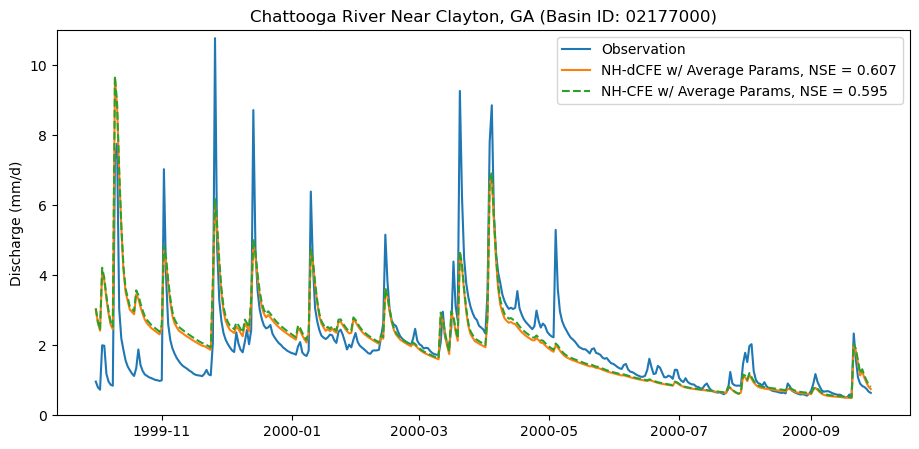

In [94]:
# Grabbing observation & predictions
dCFE_qobs_avgParams = dCFE_Result_xr_avgParams['QObs(mm/d)_obs']
dCFE_qsim_avgParams = dCFE_Result_xr_avgParams['QObs(mm/d)_sim']

# Calculate NSE manually since NH calculated it wrong
dCFE_result_avgParams_NSE = calculate_nse(dCFE_qobs_avgParams[0,:], dCFE_qsim_avgParams[0,:])
CFE_avgParams_NSE = calculate_nse(dCFE_qobs_avgParams[0,:], Discharge_avgParam[-366:-1,0]*1000)

# Plot observations and simulations
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(dCFE_Result_xr_avgParams['datetime'], dCFE_qobs_avgParams[0,:], label="Observation", color = colors[0], alpha = 1)
ax.plot(dCFE_Result_xr_avgParams['datetime'], dCFE_qsim_avgParams[0,:], label=f"NH-dCFE w/ Average Params, NSE = {dCFE_result_avgParams_NSE:.3f}",
        color = colors[1])
ax.plot(dCFE_Result_xr_avgParams['datetime'], Discharge_avgParam[-366:-1,0]*1000, label=f"NH-CFE w/ Average Params, NSE = {CFE_avgParams_NSE:.3f}",
        color = colors[2], linestyle = 'dashed')
ax.set_ylim(0, 11)
ax.set_ylabel("Discharge (mm/d)")
ax.set_title("Chattooga River Near Clayton, GA (Basin ID: 02177000)")
_ = ax.legend()

They do seem to match up. Where they differ might be due to normalizing the input data to calculate the parameters, where the manual method only normalizes over 2.5 years of data. 

### Model with Dynamic Parameters for Prediction

Grab the NH-dCFE result for calibrated spin-up & dynamic LSTM parameter prediction. 

In [95]:
# Grab results from evaluated model
run_dir_dynamic = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/TestdCFEDaily_run02177000_CalibratedSpinUpDynamic16epoch_0204_164727")
with open(run_dir_dynamic / "test" / "model_epoch016" / "test_results.p", "rb") as fp:
    dCFE_results_dynamic = pickle.load(fp)

# Extract a date slice of observations and simulations
dCFE_Result_xr_dynamic = dCFE_results_dynamic['02177000']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar_dynamic = dCFE_Result_xr_dynamic.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values_dynamic = dCFE_Result_xr_dynamic.coords['time_step'].values  # Extract as NumPy array

# Broadcast the scalar date across time_step and add the timedelta
datetime_values_dynamic = date_scalar_dynamic + pd.to_timedelta(time_step_values_dynamic, unit='D')

# Add the datetime as a new coordinate to Result_xr
dCFE_Result_xr_dynamic = dCFE_Result_xr_dynamic.assign_coords(datetime=("time_step", datetime_values_dynamic))

And then calculate the weights by hand. 

In [96]:
input_size = input_lstm.shape[2] # the num of forcings input into lstm, tmax, tmin, precip etc etc
hidden_size = config.hidden_size
num_layers = 1
output_size = 10 # satdk, cgw, and 7 other outputs
weights_path = run_dir_dynamic/"model_epoch016.pt"

torch.set_printoptions(precision=16)

# Example input data (batch_size=1, seq_length=5, input_size=10)
input_data = input_lstm

# Make predictions
LSTM_params_dynamic = load_lstm_and_predict(input_data, weights_path, input_size, hidden_size, num_layers, output_size)

And make predictions using the dynamic parameters. 


In [97]:
# empty vector to store output
Discharge_dynParam = torch.zeros(cfe_forcing2yr.shape[1], 8)

# initialize before run
constants, cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.initialize_basin_constants(
    cfg= config,
    conceptual_forcing= cfe_forcing2yr,
    cfe_params= calibrated_avgParams,
    hourly= False
    )

trimmed_LSTM_params_dynamic = LSTM_params_dynamic[:, 180:, :]
                
for i in range(0, (cfe_forcing2yr.shape[1] - config.spin_up-1)):
    cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.timestep_CFE_new(
        x_conceptual_timestep= cfe_forcing2yr[:, i, :],
        cfe_params=cfe_params,
        timestep_parameters= timestep_spinup_params,
        constants= constants,
        gw_reservoir= gw_reservoir,
        soil_reservoir= soil_reservoir,
        routing_info= routing_info,
        flux = flux,
        hourly= False
        )
    Discharge_dynParam[i, 0] = flux['Qout_m'][0]
    Discharge_dynParam[i, 1] = flux['giuh_runoff_m'][0] 
    Discharge_dynParam[i, 2] = flux['nash_lateral_runoff_m'][0]
    Discharge_dynParam[i, 3] = flux['from_deep_gw_to_chan_m'][0]
    Discharge_dynParam[i, 4] = flux['surface_runoff_depth_m'][0]
    Discharge_dynParam[i, 5] = flux['actual_et_m_per_timestep'][0] # total ET
    Discharge_dynParam[i, 6] = soil_reservoir['storage_m'][0] # soil water storage
    Discharge_dynParam[i, 7] = gw_reservoir['storage_m'][0] # gw storage

for k in range(config.spin_up, cfe_forcing2yr.shape[1]):
    
    timestep_dynParams = {
        'satdk': trimmed_LSTM_params_dynamic[0, k, 0].repeat(batch_size),
        'Cgw': trimmed_LSTM_params_dynamic[0, k, 1].repeat(batch_size),
        'bb': trimmed_LSTM_params_dynamic[0, k, 2].repeat(batch_size),
        'smcmax': trimmed_LSTM_params_dynamic[0, k, 3].repeat(batch_size),
        'slop': trimmed_LSTM_params_dynamic[0, k, 4].repeat(batch_size),
        'max_gw_storage': trimmed_LSTM_params_dynamic[0, k, 5].repeat(batch_size),
        'expon': trimmed_LSTM_params_dynamic[0, k, 6].repeat(batch_size),
        'K_lf': trimmed_LSTM_params_dynamic[0, k, 7].repeat(batch_size),
        'K_nash': trimmed_LSTM_params_dynamic[0, k, 8].repeat(batch_size),
        'satpsi': trimmed_LSTM_params_dynamic[0, k, 9].mean(dim=0).repeat(batch_size)
    }
    
    cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.timestep_CFE_new(
        x_conceptual_timestep= cfe_forcing2yr[:, k, :],
        cfe_params=cfe_params,
        timestep_parameters= timestep_dynParams,
        constants= constants,
        gw_reservoir= gw_reservoir,
        soil_reservoir= soil_reservoir,
        routing_info= routing_info,
        flux = flux,
        hourly= False
        )
    
    Discharge_dynParam[k, 0] = flux['Qout_m'][0]
    Discharge_dynParam[k, 1] = flux['giuh_runoff_m'][0] 
    Discharge_dynParam[k, 2] = flux['nash_lateral_runoff_m'][0]
    Discharge_dynParam[k, 3] = flux['from_deep_gw_to_chan_m'][0]
    Discharge_dynParam[k, 4] = flux['surface_runoff_depth_m'][0]
    Discharge_dynParam[k, 5] = flux['actual_et_m_per_timestep'][0] # total ET
    Discharge_dynParam[k, 6] = soil_reservoir['storage_m'][0] # soil water storage
    Discharge_dynParam[k, 7] = gw_reservoir['storage_m'][0] # gw storage


Plotting.

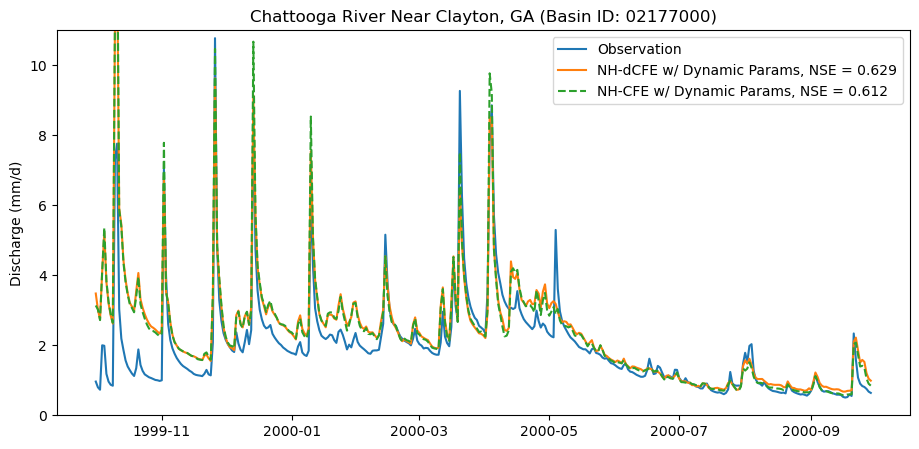

In [98]:
# Grabbing observation & predictions
dCFE_qobs_dynParams = dCFE_Result_xr_dynamic['QObs(mm/d)_obs']
dCFE_qsim_dynParams = dCFE_Result_xr_dynamic['QObs(mm/d)_sim']

# Calculate NSE manually since NH calculated it wrong
dCFE_result_dynParams_NSE = calculate_nse(dCFE_qobs_dynParams[0,:], dCFE_qsim_dynParams[0,:])
CFE_dynParams_NSE = calculate_nse(dCFE_qobs_dynParams[0,:], Discharge_dynParam[-366:-1,0]*1000)

# Plot observations and simulations
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(dCFE_Result_xr_dynamic['datetime'], dCFE_qobs_dynParams[0,:], label="Observation", color = colors[0], alpha = 1)
ax.plot(dCFE_Result_xr_dynamic['datetime'], dCFE_qsim_dynParams[0,:], label=f"NH-dCFE w/ Dynamic Params, NSE = {dCFE_result_dynParams_NSE:.3f}",
        color = colors[1])
ax.plot(dCFE_Result_xr_dynamic['datetime'], Discharge_dynParam[-366:-1,0]*1000, label=f"NH-CFE w/ Dynamic Params, NSE = {CFE_dynParams_NSE:.3f}",
        color = colors[2], linestyle = 'dashed')
ax.set_ylim(0, 11)
ax.set_ylabel("Discharge (mm/d)")
ax.set_title("Chattooga River Near Clayton, GA (Basin ID: 02177000)")
_ = ax.legend()

Note that in the above plot, NH-dCFE and "CFE w/ Dynamic LSTM Params" should match up well since those LSTM parameters are from the trained model --- they should give the same outputs. We can see that they don't match up perfectly in some areas, this might be due to normalized inputs into the LSTM where NH had a larger sample (more than 2.5yrs) and hence the normalized inputs are slightly different than this manual computation. But they are pretty close.

All simulations were spin-up for 1 year. 

Now we can say that we have succesfully validated CFE with dynamic LSTM parameters with NH-dCFE output, so the internal states of this model would be representative to that of NH-dCFE which is difficult to probe.

### Comparing Avg Params, Dynamic Params, vs. Calibrated Output
Compute the calibrated case using the HydroShare (Araki) parameters. 

In [99]:
calibrated_soil_params_validate = expand_dcfe_params_along_batch_dim(temp_soil_params_validate, batch_size)
calibrated_basinCharacteristics_validate = expand_dcfe_params_along_batch_dim(temp_basinCharacteristics_validate, batch_size)

cfe_params_validate = {
    'soil_params': calibrated_soil_params_validate,
    'basinCharacteristics': calibrated_basinCharacteristics_validate
    }

timestep_params_calibrated = {
    'satdk': calibrated_soil_params_validate['satdk'],
    'Cgw': calibrated_basinCharacteristics_validate['Cgw'],
    'bb': calibrated_soil_params_validate['bb'],
    'smcmax': calibrated_soil_params_validate['smcmax'],
    'slop': calibrated_soil_params_validate['slop'],
    'max_gw_storage': calibrated_basinCharacteristics_validate['max_gw_storage'],
    'expon': calibrated_basinCharacteristics_validate['expon'],
    'K_lf': calibrated_basinCharacteristics_validate['K_lf'],
    'K_nash': calibrated_basinCharacteristics_validate['K_nash'],
    'satpsi': calibrated_soil_params_validate['satpsi']
    }


# empty vector to store output
Discharge_caliParams = torch.zeros(cfe_forcing2yr.shape[1], 8)

# initialize before run
constants, cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.initialize_basin_constants(
    cfg= config,
    conceptual_forcing= cfe_forcing2yr,
    cfe_params= cfe_params_validate,
    hourly= False
    )

for i in range(cfe_forcing2yr.shape[1]):
    cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.timestep_CFE_new(
        x_conceptual_timestep= cfe_forcing2yr[:, i, :],
        cfe_params=cfe_params,
        timestep_parameters= timestep_params_calibrated,
        constants= constants,
        gw_reservoir= gw_reservoir,
        soil_reservoir= soil_reservoir,
        routing_info= routing_info,
        flux = flux,
        hourly= False
        )

    Discharge_caliParams[i, 0] = flux['Qout_m'][0]
    Discharge_caliParams[i, 1] = flux['giuh_runoff_m'][0] 
    Discharge_caliParams[i, 2] = flux['nash_lateral_runoff_m'][0]
    Discharge_caliParams[i, 3] = flux['from_deep_gw_to_chan_m'][0]
    Discharge_caliParams[i, 4] = flux['surface_runoff_depth_m'][0]
    Discharge_caliParams[i, 5] = flux['actual_et_m_per_timestep'][0] # total ET
    Discharge_caliParams[i, 6] = soil_reservoir['storage_m'][0] # soil water storage
    Discharge_caliParams[i, 7] = gw_reservoir['storage_m'][0] # gw storage


Now plot it.

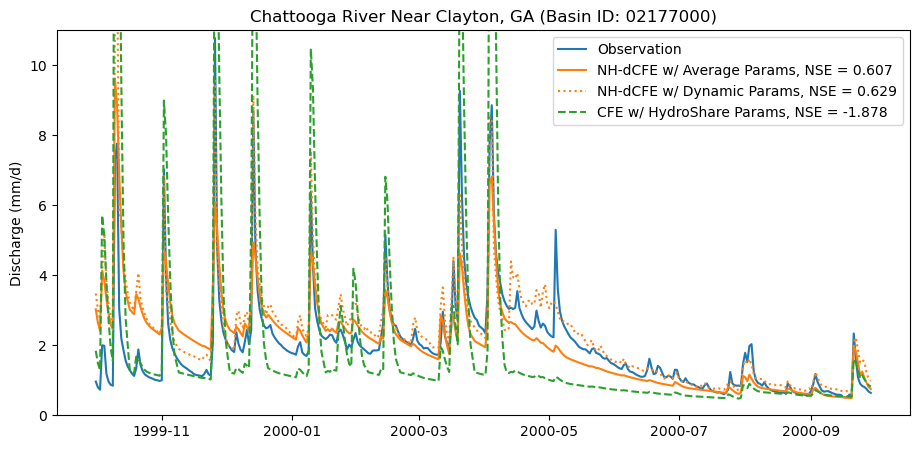

In [100]:
CFE_calibrated_NSE = calculate_nse(dCFE_qobs_dynParams[0,:], Discharge_caliParams[-366:-1,0]*1000)

# Plot observations and simulations
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(dCFE_Result_xr_dynamic['datetime'], dCFE_qobs_dynParams[0,:], label="Observation", color = colors[0], alpha = 1)
ax.plot(dCFE_Result_xr_dynamic['datetime'], dCFE_qsim_avgParams[0,:], label=f"NH-dCFE w/ Average Params, NSE = {dCFE_result_avgParams_NSE:.3f}",
        color = colors[1])
ax.plot(dCFE_Result_xr_dynamic['datetime'], dCFE_qsim_dynParams[0,:], label=f"NH-dCFE w/ Dynamic Params, NSE = {dCFE_result_dynParams_NSE:.3f}",
        color = colors[1], linestyle = 'dotted')
ax.plot(dCFE_Result_xr_dynamic['datetime'], Discharge_caliParams[-366:-1,0]*1000, label=f"CFE w/ HydroShare Params, NSE = {CFE_calibrated_NSE:.3f}",
        color = colors[2], linestyle = 'dashed')
ax.set_ylim(0, 11)
ax.set_ylabel("Discharge (mm/d)")
ax.set_title("Chattooga River Near Clayton, GA (Basin ID: 02177000)")
_ = ax.legend()

## Internal States Comparison

First, compute all variable of interest in units of (mm). This list of states of interest are adapted from what Andy said to look into. 

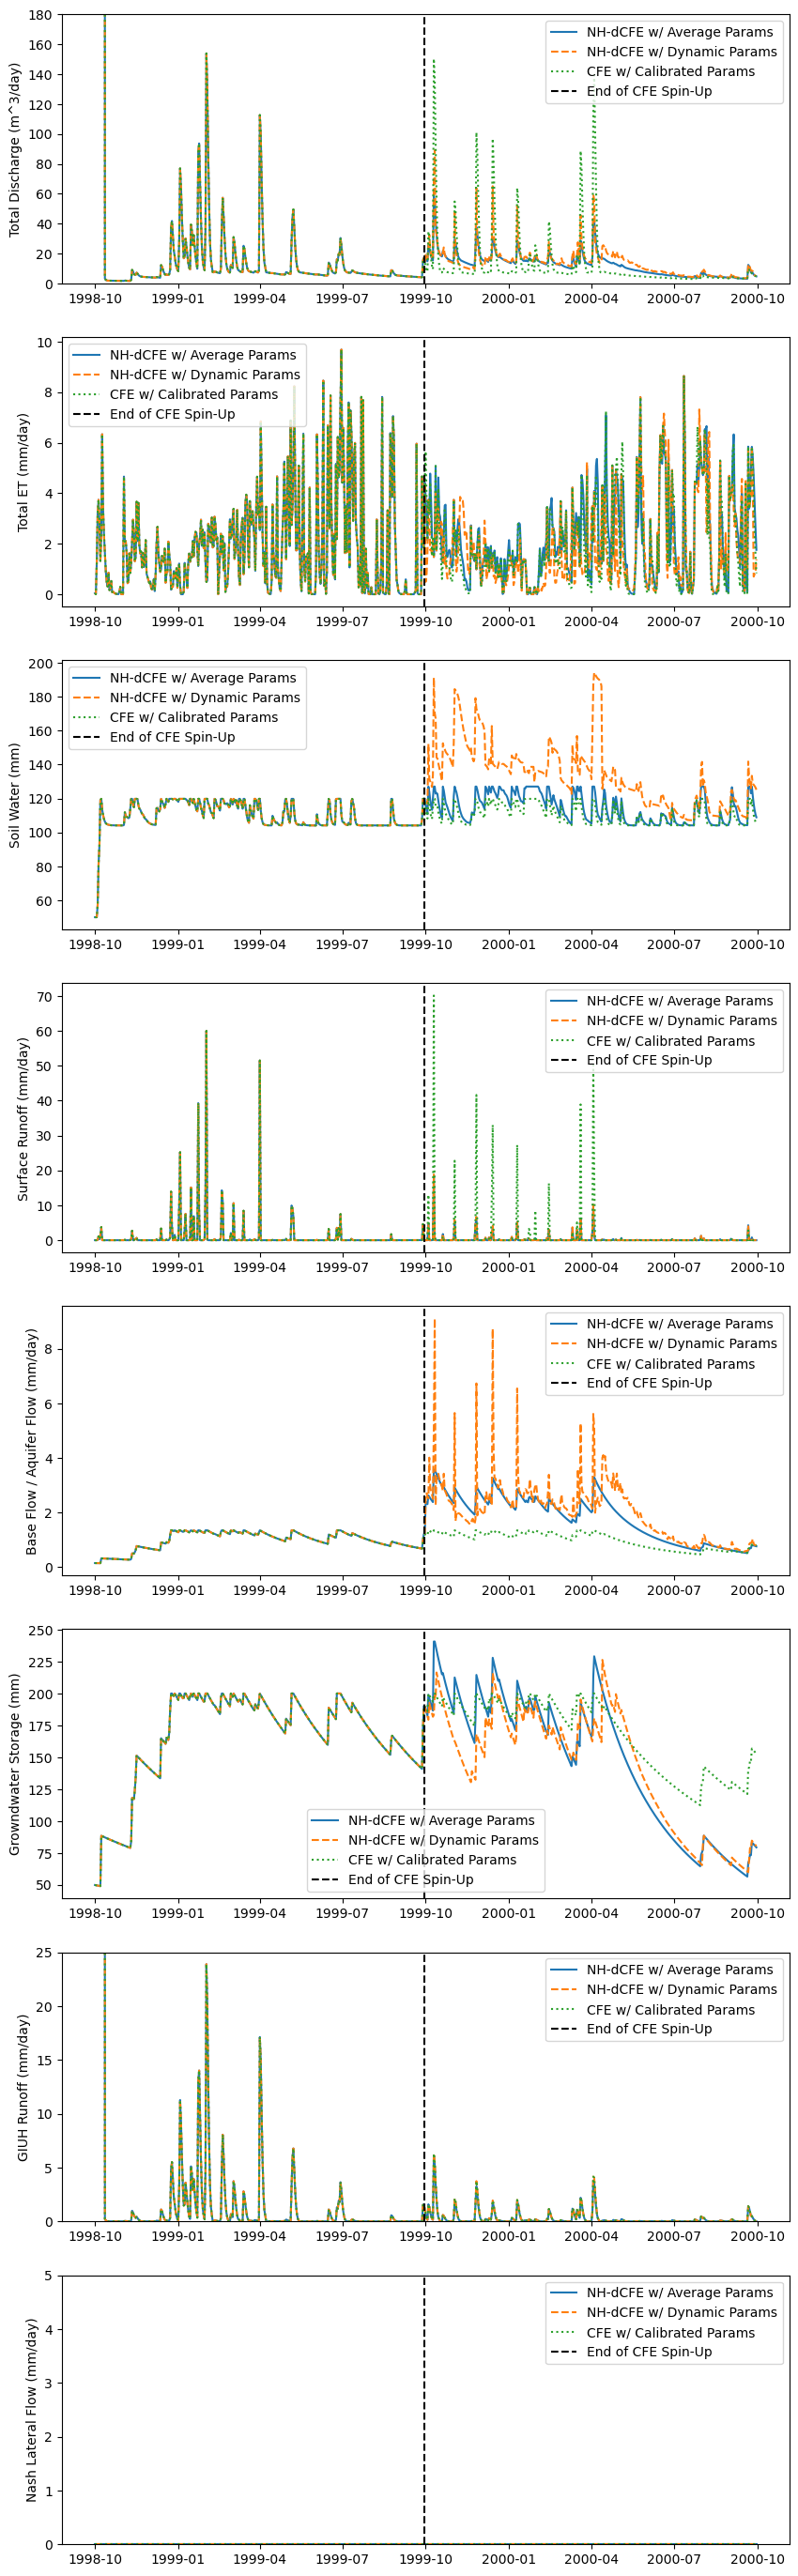

In [128]:
fig, ax = plt.subplots(8, 1, figsize=(10,35))

# plotting total discharge (m^3/day) = runoff (m/day) * area (km^2) * 1000000.0 / (3600*24)
ax[0].plot(dates_param[180:], Discharge_avgParam[:,0]*526.77 * 1000000.0 / (3600*24), label = 'NH-dCFE w/ Average Params', color = colors[0])
ax[0].plot(dates_param[180:], Discharge_dynParam[:,0]*526.77 * 1000000.0 / (3600*24), label = 'NH-dCFE w/ Dynamic Params', color = colors[1], linestyle = 'dashed')
ax[0].plot(dates_param[180:], Discharge_caliParams[:,0]*526.77 * 1000000.0 / (3600*24), label = 'CFE w/ Calibrated Params', color = colors[2], linestyle = 'dotted')
ax[0].set_ylabel("Total Discharge (m^3/day)")
# Set axis limits 
ax[0].set_ylim([0, 180])  
ax[0].legend()

# plotting total ET (mm/day) = actual_et_m_per_timestep * 1000
ax[1].plot(dates_param[180:], Discharge_avgParam[:,5]*1000, label = 'NH-dCFE w/ Average Params', color = colors[0])
ax[1].plot(dates_param[180:], Discharge_dynParam[:,5]*1000, label = 'NH-dCFE w/ Dynamic Params', color = colors[1], linestyle = 'dashed')
ax[1].plot(dates_param[180:], Discharge_caliParams[:,5]*1000, label = 'CFE w/ Calibrated Params', color = colors[2], linestyle = 'dotted')
ax[1].set_ylabel("Total ET (mm/day)")
ax[1].legend()

# plotting soil water storage (mm) = soil_storage_m * 1000
ax[2].plot(dates_param[180:], Discharge_avgParam[:,6]*1000, label = 'NH-dCFE w/ Average Params', color = colors[0])
ax[2].plot(dates_param[180:], Discharge_dynParam[:,6]*1000, label = 'NH-dCFE w/ Dynamic Params', color = colors[1], linestyle = 'dashed')
ax[2].plot(dates_param[180:], Discharge_caliParams[:,6]*1000, label = 'CFE w/ Calibrated Params', color = colors[2], linestyle = 'dotted')
ax[2].set_ylabel("Soil Water (mm)")
ax[2].legend()

# plotting surface flow (mm/day) = surface_runoff_depth_m * 1000
ax[3].plot(dates_param[180:], Discharge_avgParam[:,4]*1000, label = 'NH-dCFE w/ Average Params', color = colors[0])
ax[3].plot(dates_param[180:], Discharge_dynParam[:,4]*1000, label = 'NH-dCFE w/ Dynamic Params', color = colors[1], linestyle = 'dashed')
ax[3].plot(dates_param[180:], Discharge_caliParams[:,4]*1000, label = 'CFE w/ Calibrated Params', color = colors[2], linestyle = 'dotted')
ax[3].set_ylabel("Surface Runoff (mm/day)")
ax[3].legend()

# plotting base flow / aquifer flow (mm/day) = flux_from_deep_gw_to_chan_m * 1000
ax[4].plot(dates_param[180:], Discharge_avgParam[:,3]*1000, label = 'NH-dCFE w/ Average Params', color = colors[0])
ax[4].plot(dates_param[180:], Discharge_dynParam[:,3]*1000, label = 'NH-dCFE w/ Dynamic Params', color = colors[1], linestyle = 'dashed')
ax[4].plot(dates_param[180:], Discharge_caliParams[:,3]*1000, label = 'CFE w/ Calibrated Params', color = colors[2], linestyle = 'dotted')
ax[4].set_ylabel("Base Flow / Aquifer Flow (mm/day)")
ax[4].legend()

# plotting groundwater storage (mm) = gw_storage_m* 1000
ax[5].plot(dates_param[180:], Discharge_avgParam[:,7]*1000, label = 'NH-dCFE w/ Average Params', color = colors[0])
ax[5].plot(dates_param[180:], Discharge_dynParam[:,7]*1000, label = 'NH-dCFE w/ Dynamic Params', color = colors[1], linestyle = 'dashed')
ax[5].plot(dates_param[180:], Discharge_caliParams[:,7]*1000, label = 'CFE w/ Calibrated Params', color = colors[2], linestyle = 'dotted')
ax[5].set_ylabel("Growndwater Storage (mm)")
ax[5].legend()

# plotting GIUH flow (mm/day) = flux_giuh_runoff_m * 1000
ax[6].plot(dates_param[180:], Discharge_avgParam[:,1]*1000, label = 'NH-dCFE w/ Average Params', color = colors[0])
ax[6].plot(dates_param[180:], Discharge_dynParam[:,1]*1000, label = 'NH-dCFE w/ Dynamic Params', color = colors[1], linestyle = 'dashed')
ax[6].plot(dates_param[180:], Discharge_dynParam[:,1]*1000, label = 'CFE w/ Calibrated Params', color = colors[2], linestyle = 'dotted')
ax[6].set_ylabel("GIUH Runoff (mm/day)")
ax[6].set_ylim([0, 25])  
ax[6].legend()

# plotting Nash Lateral Flow (mm/day) = flux_nash_lateral_runoff_m * 1000
ax[7].plot(dates_param[180:], Discharge_avgParam[:,2]*1000, label = 'NH-dCFE w/ Average Params', color = colors[0])
ax[7].plot(dates_param[180:], Discharge_dynParam[:,2]*1000, label = 'NH-dCFE w/ Dynamic Params', color = colors[1], linestyle = 'dashed')
ax[7].plot(dates_param[180:], Discharge_caliParams[:,2]*1000, label = 'CFE w/ Calibrated Params', color = colors[2], linestyle = 'dotted')
ax[7].set_ylabel("Nash Lateral Flow (mm/day)")
ax[7].set_ylim([0, 5])  
ax[7].legend()

for i in range(8):
    ax[i].axvline(pd.Timestamp('1999-09-30'), color="black", linestyle='--', label='End of CFE Spin-Up') 
    ax[i].legend()

## Parameter Comparison

In [ ]:
LSTM_params[0, (180+366):, 0]

tensor([])

In [143]:
LSTM_avgParam = torch.zeros(10)
for i in range(LSTM_avgParam.shape[0]):
    LSTM_avgParam[i] = LSTM_params[0, (180+366):, i].mean()
CFE_cali = torch.zeros(10)
CFE_cali[0] = calibrated_soil_params_validate['satdk'][0]
CFE_cali[1] = calibrated_basinCharacteristics_validate['Cgw'][0]
CFE_cali[2] = calibrated_soil_params_validate['bb'][0]
CFE_cali[3] = calibrated_soil_params_validate['smcmax'][0]
CFE_cali[4] = calibrated_soil_params_validate['slop'][0]
CFE_cali[5] = calibrated_basinCharacteristics_validate['max_gw_storage'][0]
CFE_cali[6] = calibrated_basinCharacteristics_validate['expon'][0]
CFE_cali[7] = calibrated_basinCharacteristics_validate['K_lf'][0]
CFE_cali[8] = calibrated_basinCharacteristics_validate['K_nash'][0]
CFE_cali[9] = calibrated_soil_params_validate['satpsi'][0]

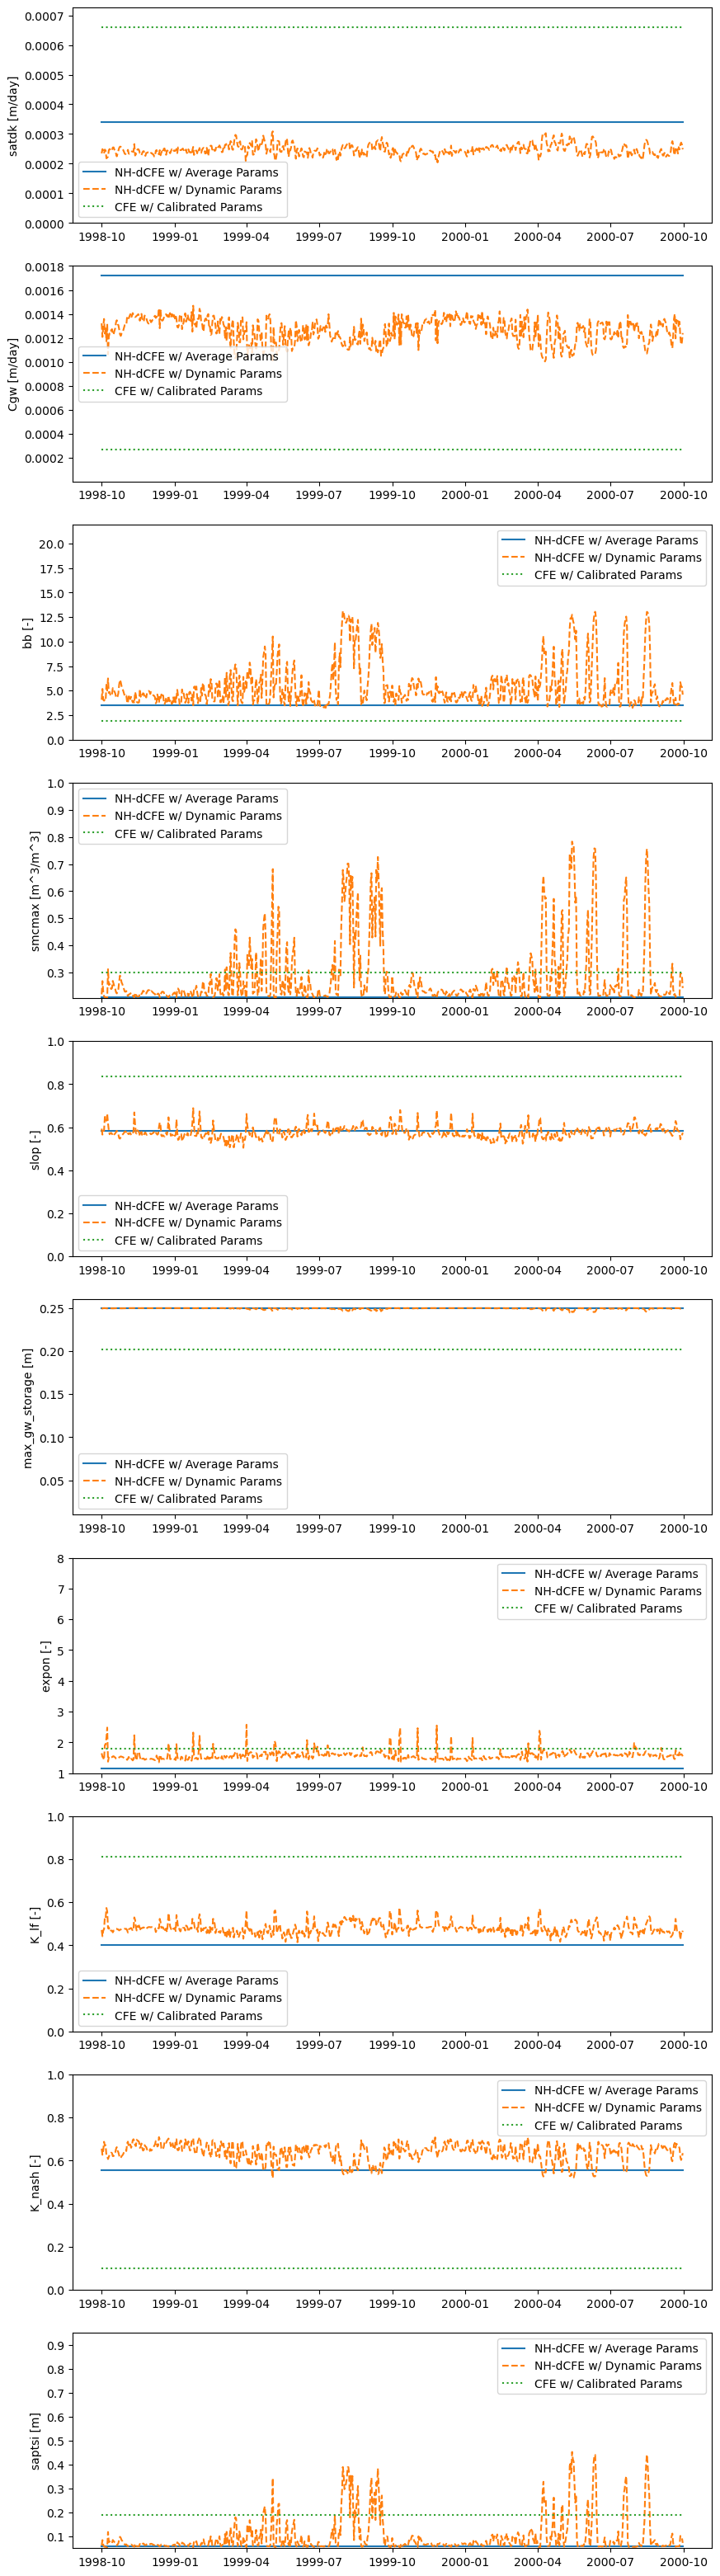

In [145]:
param_names = ['satdk', 'Cgw', 'bb', 'smcmax', 'slop', 'max_gw_storage', 'expon', 'K_lf', 'K_nash', 'saptsi']
param_units = ['[m/day]', '[m/day]', '[-]', '[m^3/m^3]', '[-]', '[m]', '[-]', '[-]', '[-]', '[m]'] # [-] means unitless
lower_lim = [0.0, 0.0000018, 0.0, 0.20554, 0.0, 0.01, 1.0, 0.0, 0.0, 0.05]
upper_lim = [0.000726, 0.0018, 21.94, 1.0, 1.0, 0.26, 8.0, 1.0, 1.0, 0.95]

fig, ax = plt.subplots(10, 1, figsize=(10,40))
dates = dates_param[180:]
n = len(dates)

for i in range(10):
    # 1) Broadcast scalars to length n
    avg_line  = torch.full((n,), LSTM_avgParam[i].item())
    cali_line = torch.full((n,), CFE_cali[i].item())

    ax[i].plot(dates, avg_line,
               label='NH-dCFE w/ Average Params',
               color=colors[0])
    ax[i].plot(dates,
               LSTM_params_dynamic[0, 180:, i].cpu().numpy(),
               label='NH-dCFE w/ Dynamic Params',
               color=colors[1], linestyle='dashed')
    ax[i].plot(dates, cali_line,
               label='CFE w/ Calibrated Params',
               color=colors[2], linestyle='dotted')
    ax[i].set_ylim([lower_lim[i], upper_lim[i]])  
    ax[i].set_ylabel(f"{param_names[i]} {param_units[i]}")
    # Add a legend
    ax[i].legend()

# Poster Graphics

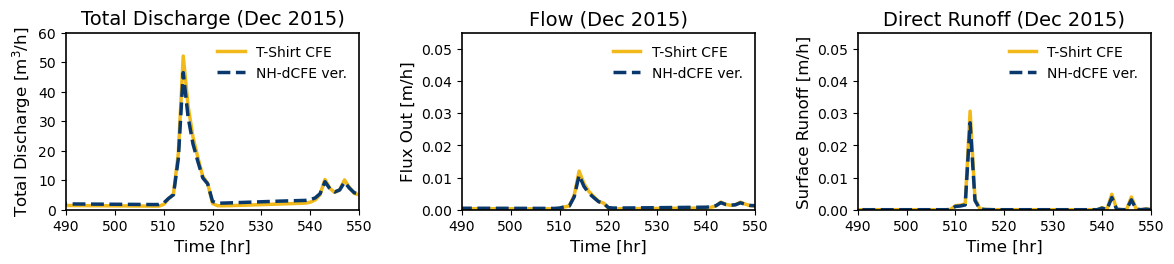

In [92]:
with plt.style.context({'axes.titlesize':14,
                        'axes.labelsize':12,
                        'xtick.labelsize':10,
                        'ytick.labelsize':10,
                        'legend.fontsize':10,
                        'lines.linewidth':    2.5,   # <— makes all plot lines thicker
                        'axes.linewidth':     1.2 # <— (optional) makes the axis borders thicker
                        }):

    fig, ax = plt.subplots(1, 3, figsize=(14,2.3))

    ax[0].plot(compareFile['Time Step'], compareFile['Total Discharge'], label="T-Shirt CFE", 
            color = minesColors['goldenTech'])
    ax[0].plot(compareFile['Time Step'], Discharge[:,0]*15.617167355002097 * 1000000.0 / 3600 , 
            label="NH-dCFE ver.", color = minesColors['blasterBlue'], linestyle= 'dashed')
    # Set labels and title
    ax[0].set_ylabel(r"Total Discharge [$\mathrm{m}^3/\mathrm{h}$]")
    ax[0].set_title(f"Total Discharge (Dec 2015)")
    ax[0].set_xlabel(f"Time [hr]")
    # Set axis limits
    ax[0].set_xlim([490, 550]) 
    ax[0].set_ylim([0, 60])  
    ax[0].legend(frameon=False)

    ax[1].plot(compareFile['Time Step'], compareFile['Flow'], label="T-Shirt CFE", 
            color = minesColors['goldenTech'])
    ax[1].plot(compareFile['Time Step'], Discharge[:,0], label="NH-dCFE ver.", 
            color = minesColors['blasterBlue'], linestyle= 'dashed')

    # Set labels and title
    ax[1].set_ylabel("Flux Out [m/h]")
    ax[1].set_title(f"Flow (Dec 2015)")
    ax[1].set_xlabel(f"Time [hr]")
    # Set axis limits
    ax[1].set_xlim([490, 550])  
    ax[1].set_ylim([0, 0.055])  
    ax[1].legend(frameon=False)

    ax[2].plot(compareFile['Time Step'], compareFile['Direct Runoff'],label="T-Shirt CFE", color = minesColors['goldenTech'])
    ax[2].plot(compareFile['Time Step'], Discharge[:,4], label="NH-dCFE ver.",
            color = minesColors['blasterBlue'], linestyle= 'dashed')

    # Set labels and title
    ax[2].set_ylabel("Surface Runoff [m/h]")
    ax[2].set_title(f"Direct Runoff (Dec 2015)")
    ax[2].set_xlabel(f"Time [hr]")
    # Set axis limits
    ax[2].set_xlim([490, 550]) 
    ax[2].set_ylim([0, 0.055])  
    ax[2].legend(frameon=False)

    fig.subplots_adjust(wspace=0.35, hspace=0.2)  

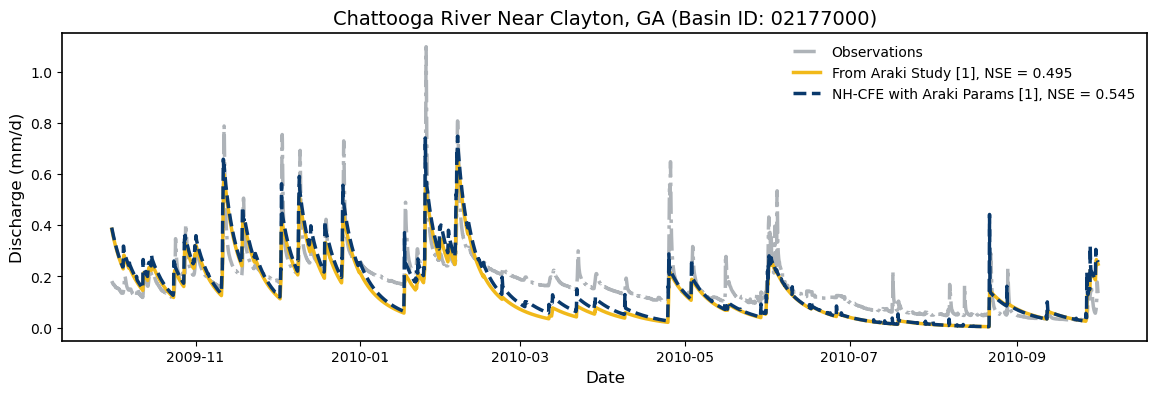

In [90]:
# Plot observations and simulations
with plt.style.context({'axes.titlesize':14,
                        'axes.labelsize':12,
                        'xtick.labelsize':10,
                        'ytick.labelsize':10,
                        'legend.fontsize':10,
                        'lines.linewidth':    2.5,   # <— makes all plot lines thicker
                        'axes.linewidth':     1.2  # <— (optional) makes the axis borders thicker
                        }):
        
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(date_validate, observation_validate[-length_validate:], 
                label="Observations", linestyle='-.', color = minesColors['lightGray'])
        ax.plot(date_validate, runoff_simulation_validate, label=f"From Araki Study [1], NSE = {NSE_HydroShare:.3f}",
                color = minesColors['goldenTech'])
        ax.plot(date_validate, Discharge_validate[-length_validate:,0] * 1000, 
                label=f"NH-CFE with Araki Params [1], NSE = {NSE_NHCFE:.3f}", linestyle='dashed',
                color = minesColors['blasterBlue'])
        ax.set_ylabel("Discharge (mm/d)")
        ax.set_xlabel("Date")
        ax.set_title("Chattooga River Near Clayton, GA (Basin ID: 02177000)")
        _ = ax.legend(frameon=False)

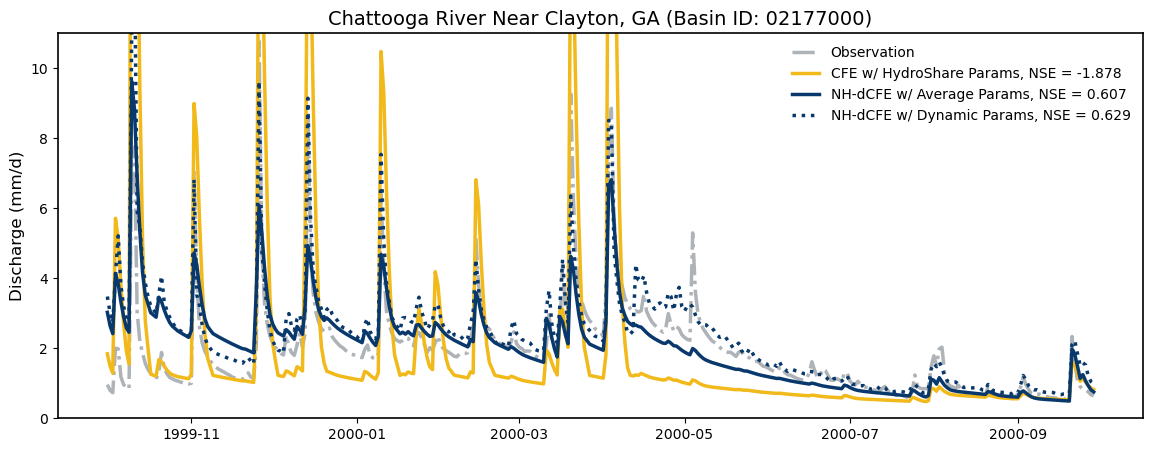

In [ ]:
# Plot observations and simulations
with plt.style.context({'axes.titlesize':14,
                        'axes.labelsize':12,
                        'xtick.labelsize':10,
                        'ytick.labelsize':10,
                        'legend.fontsize':10,
                        'lines.linewidth':    2.5,   # <— makes all plot lines thicker
                        'axes.linewidth':     1.2  # <— (optional) makes the axis borders thicker
                        }):
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(dCFE_Result_xr_dynamic['datetime'], dCFE_qobs_dynParams[0,:], label="Observation", linestyle='-.', color = minesColors['lightGray'])
        ax.plot(dCFE_Result_xr_dynamic['datetime'], Discharge_caliParams[-366:-1,0]*1000, label=f"CFE w/ Araki Params [1], NSE = {CFE_calibrated_NSE:.3f}",
                color = minesColors['goldenTech'])
        ax.plot(dCFE_Result_xr_dynamic['datetime'], dCFE_qsim_avgParams[0,:], label=f"NH-dCFE w/ Static Params, NSE = {dCFE_result_avgParams_NSE:.3f}",
                color = minesColors['blasterBlue'])
        ax.plot(dCFE_Result_xr_dynamic['datetime'], dCFE_qsim_dynParams[0,:], label=f"NH-dCFE w/ Dynamic Params, NSE = {dCFE_result_dynParams_NSE:.3f}",
                color = minesColors['blasterBlue'], linestyle = 'dotted')
        
        ax.set_ylim(0, 11)
        ax.set_ylabel("Discharge (mm/d)")
        ax.set_title("Chattooga River Near Clayton, GA (Basin ID: 02177000)")
        _ = ax.legend(frameon=False)